In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets,transforms
import numpy as np
import time
import matplotlib
from matplotlib import pyplot as pp
import scipy
from scipy.integrate import odeint
import random
import functools
#from training_data import ground_truth

In [36]:
###use mps as device; you have to change this to another device if you work with cuda or with cpu etc.
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print(device)
else:
    device = torch.device("cpu")
    print("MPS device not found! Using cpu instead")

mps


In [37]:
#GPU
start = time.time()
#synchronize with cpu
torch.mps.synchronize()
a = torch.ones(4000,4000,device="mps")
for _ in range(200):
    a=+a
elapsed_time = time.time() - start
print("GPU TIME",elapsed_time)

GPU TIME 0.0012111663818359375


We try to solve Newton's law of cooling 

$$
\frac{dT(t)}{dt}=r(T_{env} - T(t)) \\
$$

And predict the Temperature T of a cup of coffee boiling at a temperature (100 celsius); we assume we want to predict T for 1000 seconds but we only have a few samples of the temperature for the first 300 seconds. I can assume that T in the environment is 25 Celsius and the cooling rate is 0.005 ()

### Step 1: Ground truth data
1. Collect ground truth for 1000 seconds period based on known solution of simple first-order differential equation
2. Creating the "ground truth" by solving the differential equation using python's library functools; I could have also used the odeint package in scipy! 

In [ ]:
###defining the function using functional tools###

def cooling_law(time, te, to, r): #te is T of en
    T = te + (to - te) * np.exp(-r * time)
    return T



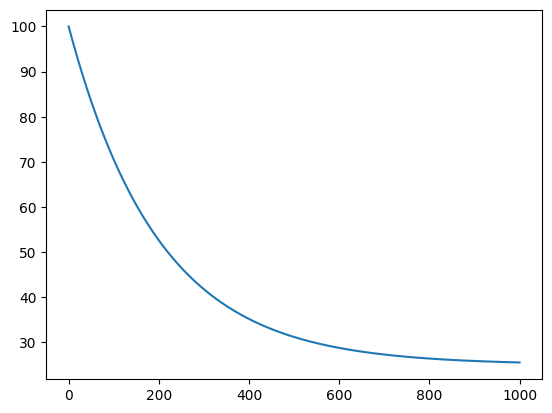

In [39]:
#ground truth data; I use
t0 = 100
te = 25
r  = 0.005
start_time = 0
end_time = 1000
sampl_freq = 1000
np.random.seed(10)
times = np.linspace(start_time,end_time,sampl_freq)
eq = functools.partial(cooling_law,te=te,to=t0,r=r)
temps = eq(times)
pp.plot(times,temps)

### Step 2: Small sample for function estimation using NNs
1. Sample 10 data points for the first 300 seconds
2. Add some noise to the sample

In [40]:
#Sampling the training data
time = np.linspace(0, 300, 10)
T_sample_noise = eq(time) +  2 * np.random.randn(10)
#T_sample_noises = eq(time) + np.random.normal(loc=0.0,scale=1)
print(T_sample_noise)
#print(T_sample_noise - eq(time),)


[102.66317301  89.91668732  75.64904771  70.47303178  64.74895588
  56.15469452  53.12198126  48.57233885  44.77836822  41.38556159]


Text(0.5, 0, 'Time (s)')

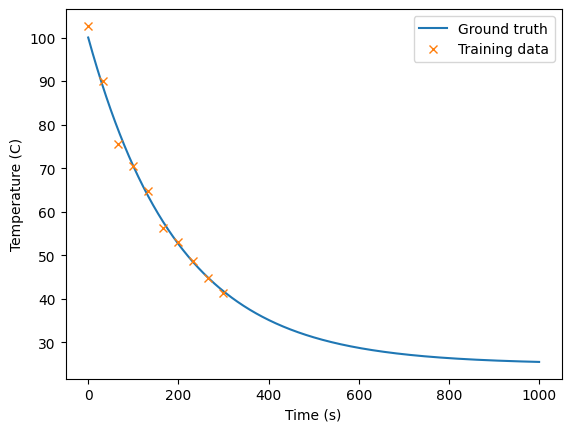

In [41]:
pp.plot(times,temps)
pp.plot(time,T_sample_noise,'x')
pp.legend(['Ground truth', 'Training data'])
pp.ylabel('Temperature (C)')
pp.xlabel('Time (s)')

### Step 3: Simple Neural Networks with and without regularization
1. Defining the simple Vanilla NN with all neutrons connected and three hidden layers;
* we use ReLU activiation function
* the output is 1 in this case
*  hidden layers have a size of 100 (100 neurons); this can be changed later

In [42]:
#define the dimensions: https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module
input_dim=1
output_dim=1

class network(nn.Module):
    def __init__(self,input_dim, out_dim,n_units=100)-> None: ### if you use the Module parent class you always have to initiate a subclass first/parent child
        super().__init__()
        self.n_units = n_units
        self.layers = nn.Sequential(
            nn.Linear(input_dim, self.n_units),
            nn.ReLU(),
            nn.Linear(self.n_units, self.n_units),
            nn.ReLU(),
            nn.Linear(self.n_units, self.n_units),
            nn.ReLU(),
            nn.Linear(self.n_units, self.n_units),
            nn.ReLU(),
        )
        self.out = nn.Linear(self.n_units,out_dim)
    def forward(self,x): ### what does this actually do? 
        h =self.layers(x)
        return self.out(h)
    



    
  




### Step 4: Train the model the model and make predictions using 10 sample data points
1. We use Adam as optimizer
2. MSE as loss (might not be good because of small sample size but can be changed)
3. Explore L2 regularization ( I try different weights)
4. Hyperparameters: 2000 epochs, lr=1e^5, regularization parameters on a range from 0 to 0.003

For a simple MSE loss we use the following loss function (second option is with regularization)
$$
Loss = \frac{1}{N} \sum_{1}^{N} (y_{i} - \^{y_{i}})^2
$$
$$
Loss_{reg} = \frac{1}{N} \sum_{1}^{N} (f(x_{i}|\Theta) - \^{y_{i}})^2 - \lambda \|\Theta\|
$$

network(
  (layers): Sequential(
    (0): Linear(in_features=1, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=100, bias=True)
    (5): ReLU()
    (6): Linear(in_features=100, out_features=100, bias=True)
    (7): ReLU()
  )
  (out): Linear(in_features=100, out_features=1, bias=True)
) 0
MSELoss()
torch.Size([10, 1]) torch.Size([10, 1])
Epoch 0/20000,loss: 4477.322
Epoch 2000/20000,loss: 2498.002
Epoch 4000/20000,loss: 1972.908
Epoch 6000/20000,loss: 446.914
Epoch 8000/20000,loss: 4.625
Epoch 10000/20000,loss: 2.414
Epoch 12000/20000,loss: 2.355
Epoch 14000/20000,loss: 2.346
Epoch 16000/20000,loss: 2.335
Epoch 18000/20000,loss: 2.330
Epoch 20000/20000,loss: 2.330
<class 'list'>
network(
  (layers): Sequential(
    (0): Linear(in_features=1, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): ReLU()
    

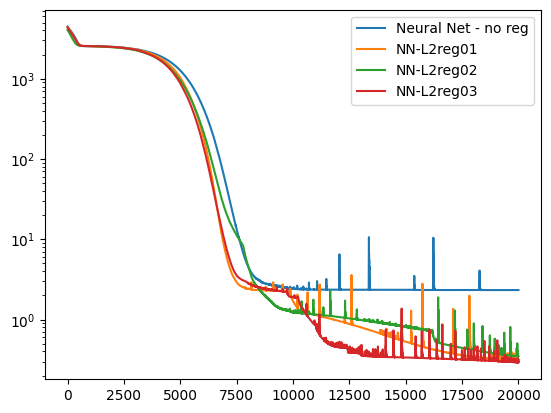

In [43]:
np.random.seed(10)
#torch.manual_seed(42)

epochs = 20000
lr = 1e-5
weight_decay=[0,0.001,0.002,0.003]
models = []
for weight in weight_decay:
    model = network(1,1,100).to(device)
    print(model,weight)
    optimizer =torch.optim.Adam(model.parameters(),lr=lr,weight_decay=weight)
    criterion = nn.MSELoss()
    print(criterion)

    #np to torch#   
    X = torch.from_numpy(time).to(torch.float).to(device).reshape(len(time),-1)
    Y = torch.from_numpy(T_sample_noise).to(torch.float).to(device).reshape(len(T_sample_noise),-1)
    print(X.size(),Y.size())
    losses =[]
    model.train()
    for epoch in range(epochs+1):
        ##forward pass
        optimizer.zero_grad() #this zeros out the gradients
        output =model.forward(X)
        loss =criterion(Y,output)
        loss.backward()
        ##update weights
        optimizer.step()
        #update losses, print progress
        losses.append(loss.item())
        if epoch % int(epochs/10) == 0:
            print(f"Epoch {epoch}/{epochs},loss: {losses[-1]:.3f}")
    #safe models
    models.append(model)
    print(type(losses))
    pp.plot(losses)
    pp.yscale('log')
    pp.legend(['Neural Net - no reg','NN-L2reg01','NN-L2reg02','NN-L2reg03'])

In [44]:
models

[network(
   (layers): Sequential(
     (0): Linear(in_features=1, out_features=100, bias=True)
     (1): ReLU()
     (2): Linear(in_features=100, out_features=100, bias=True)
     (3): ReLU()
     (4): Linear(in_features=100, out_features=100, bias=True)
     (5): ReLU()
     (6): Linear(in_features=100, out_features=100, bias=True)
     (7): ReLU()
   )
   (out): Linear(in_features=100, out_features=1, bias=True)
 ),
 network(
   (layers): Sequential(
     (0): Linear(in_features=1, out_features=100, bias=True)
     (1): ReLU()
     (2): Linear(in_features=100, out_features=100, bias=True)
     (3): ReLU()
     (4): Linear(in_features=100, out_features=100, bias=True)
     (5): ReLU()
     (6): Linear(in_features=100, out_features=100, bias=True)
     (7): ReLU()
   )
   (out): Linear(in_features=100, out_features=1, bias=True)
 ),
 network(
   (layers): Sequential(
     (0): Linear(in_features=1, out_features=100, bias=True)
     (1): ReLU()
     (2): Linear(in_features=100, out_fea

<class 'list'>


Text(0.5, 0, 'Time (s)')

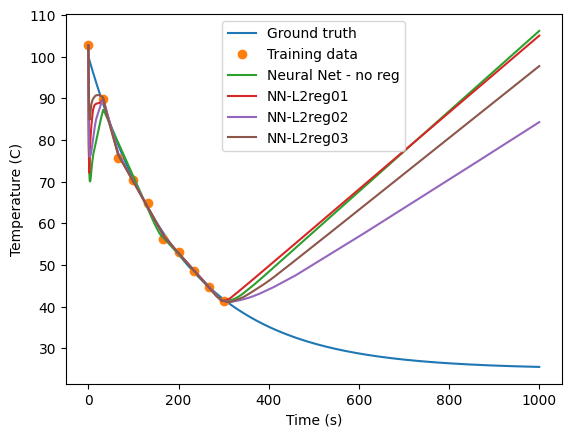

In [45]:
#predictions for the different models plotted
predictations = []
for model in models:
    model.eval()
    XT = torch.from_numpy(times).to(torch.float).to(device).reshape(len(times),-1)
    out = model.forward(XT)
    preds =out.detach().cpu().numpy()
    predictations.append(preds)
print(type(predictations))
pp.plot()
pp.plot(times,temps)
pp.plot(time,T_sample_noise,'o')
pp.plot(times, predictations[0])
pp.plot(times, predictations[1]) 
pp.plot(times, predictations[2])
pp.plot(times, predictations[3])
pp.legend(['Ground truth', 'Training data','Neural Net - no reg','NN-L2reg01','NN-L2reg02','NN-L2reg03'])
pp.ylabel('Temperature (C)')
pp.xlabel('Time (s)')
    #pp.plot(times, preds, alpha=0.8)

Now I am trying to do the regularization by hand! 


In [46]:

def l2_reg(model:torch.nn.Module):
    return torch.sum(sum([p.pow(2) for p in model.parameters()]))



torch.Size([10, 1]) torch.Size([10, 1])
Epoch 0/20000,loss: 10851.453
Epoch 2000/20000,loss: 3512.616
Epoch 4000/20000,loss: 1965.156
Epoch 6000/20000,loss: 1116.480
Epoch 8000/20000,loss: 717.578
Epoch 10000/20000,loss: 574.089
Epoch 12000/20000,loss: 514.814
Epoch 14000/20000,loss: 475.087
Epoch 16000/20000,loss: 437.498
Epoch 18000/20000,loss: 405.882
<class 'list'>


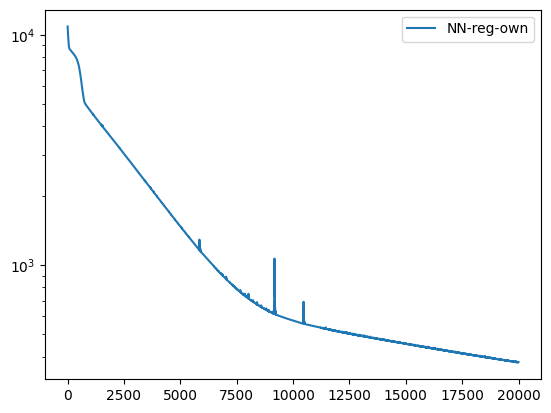

In [47]:
#np.random.seed(10)
#torch.manual_seed(42)

epochs = 20000
lr = 1e-4
#weights = [0,1]
modelts = []

#for w in weights:
losses =[]
modelt = network(1,1,100).to(device)
optimizer =torch.optim.Adam(modelt.parameters(),lr=lr)
#np to torch#   
X = torch.from_numpy(time).to(torch.float).to(device).reshape(len(time),-1)
Y = torch.from_numpy(T_sample_noise).to(torch.float).to(device).reshape(len(T_sample_noise),-1)
print(X.size(),Y.size())
#print(f"This is with the weight:{w:.3f}")
modelt.train()
for epoch in range(epochs):
    ##forward pass
    optimizer.zero_grad() #this zeros out the gradients
    output =modelt.forward(X)
    dataloss =nn.MSELoss()
    loss = dataloss(Y,output) + l2_reg(modelt)
    loss.backward()
    ##update weights
    optimizer.step()
    #update losses, print progress
    losses.append(loss.item())
    if epoch % int(epochs/10) == 0:
        print(f"Epoch {epoch}/{epochs},loss: {losses[-1]:.3f}")
#safe models
modelts.append(modelt)
print(type(losses))
pp.plot(losses)
pp.yscale('log')
pp.legend(['NN-reg-own'])

<class 'list'>


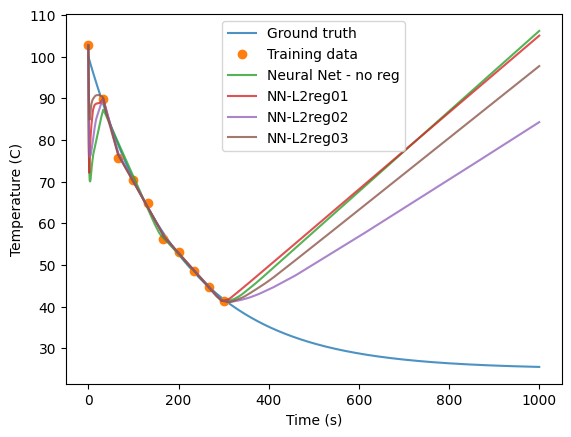

In [48]:
#predictions for the different models plotted
#predictations = []
for modelt in modelts:
    modelt.eval()
    XT = torch.from_numpy(times).to(torch.float).to(device).reshape(len(times),-1)
    out = modelt.forward(XT)
    preds =out.detach().cpu().numpy()
    predictations.append(preds)
print(type(predictations))
pp.plot()
pp.plot(times,temps,alpha=0.8)
pp.plot(time,T_sample_noise,'o')
for i in range(0,len(predictations)-1):
    pp.plot(times, predictations[i],alpha=0.8)
    pp.legend(['Ground truth', 'Training data','Neural Net - no reg','NN-L2reg01','NN-L2reg02','NN-L2reg03','NN-L2own'])
    pp.ylabel('Temperature (C)')
    pp.xlabel('Time (s)')
    #pp.plot(times, preds, alpha=0.8)

### Step 5: Building a PINNs model

In [49]:
len(predictations)

5

In [50]:
# Now I am creating a PINNs where I adjust the loss using a differential equation

def grad(outputs,inputs):
    """Computes the partial derivative of an output with respect to the input
    Args: 
        outputs: (N,1) tensors (since we have only 1-dimensional output in our example)
        inputs: (N,D) tensors 
    
    """
    return torch.autograd.grad(
        outputs,inputs, grad_outputs=torch.ones_like(outputs), create_graph = True #one_like retains the data type of the output
    )

$$
Loss_{reg} = Loss_{data} + Loss_{physics}
$$

$$
Loss_{reg} = \frac{1}{N} \sum_{j}^{N} (y_{j} - \^{y_{j}})^2 + \lambda \frac{1}{M} \sum_{i}^{M} \|g(x_{i},f(x_{i}|\theta)\|^2_{2}
$$


To incorporate the physics loss for this particular example, I would use the first order differential equation in the neural network that predicts the temperature T of a cup coffee at time t, then i can calculate the following physics loss: 
$$
g(t,T) = \frac{dT(t)}{dt} - r(T_{env} - T(t)) = 0 \\
$$
$$
g(t,df(t| \theta)) = \frac{df(t| \theta)}{dt} - r(T_{env} - df(t| \theta)) = 0 \\
$$
$$
Loss_{physics} = \lambda \frac{1}{M} \sum_{i}^{M} (\frac{df(t|\theta)}{dt} - r(T_{env} - df(t| \theta)))^2
$$
$$
Loss_{reg} = \frac{1}{10} \sum_{j}^{10} (y_{j} - \^{y_{j}})^2 + \lambda \frac{1}{M} \sum_{i}^{M} (\frac{df(t|\theta)}{dt} - r(T_{env} - df(t| \theta)))^2
$$

> So what I have to do is I have to take the derivate of the neural network and for that I use the autograd functionality from Pytorch (see the autograd function above)

In [51]:
def physics_loss(model:torch.nn.Module):
    ts = torch.linspace(0, 1000, steps=1000,).view(-1,1).requires_grad_(True).to(device)
    #print(model)
    temps = model(ts)
    dT = grad(temps,ts)[0]
    ode = dT - 0.005*(25 - temps)
    p_loss = torch.mean(ode**2)
    return p_loss

network_test = network(1,1,100).to(device)

# temps = model(ts)
# dT = grad(temps,ts)[0]
# print(type(dT))
# ode = dT - 0.005*(25 - temps)
# #print(ode)
# p_loss = torch.mean(ode**2).clone().detach().requires_grad_(True)
# print(p_loss, type(p_loss))

print(physics_loss(network_test))



    


tensor(0.0162, device='mps:0', grad_fn=<MeanBackward0>)


network(
  (layers): Sequential(
    (0): Linear(in_features=1, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=100, bias=True)
    (5): ReLU()
    (6): Linear(in_features=100, out_features=100, bias=True)
    (7): ReLU()
  )
  (out): Linear(in_features=100, out_features=1, bias=True)
) 0.001
torch.Size([10, 1]) torch.Size([10, 1])
Epoch 0/20000,loss: 4713.900
('layers.0.weight', Parameter containing:
tensor([[ 0.7645],
        [ 0.8300],
        [-0.2343],
        [ 0.9186],
        [-0.2191],
        [ 0.2018],
        [-0.4868],
        [ 0.5873],
        [ 0.8816],
        [-0.7336],
        [ 0.8692],
        [ 0.1871],
        [ 0.7388],
        [ 0.1354],
        [ 0.4822],
        [-0.1412],
        [ 0.7709],
        [ 0.1478],
        [-0.4668],
        [ 0.2549],
        [-0.4607],
        [-0.1173],
        [-0.4061],
        [ 0.6634],
        [-0.7894],

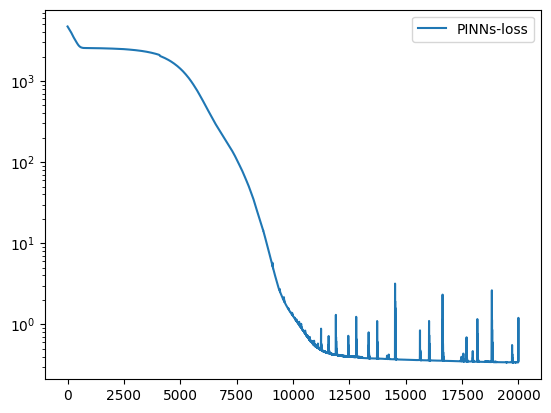

In [ ]:
torch.manual_seed(42)
epochs = 20000
lr = 1e-5
weight=0.001
modelp = network(1,1,100).to(device)
print(modelp,weight)
optimizer =torch.optim.Adam(modelp.parameters(),lr=lr,weight_decay=weight)

#np to torch#   
#X = torch.from_numpy(time).to(torch.float).to(device).reshape(len(time),-1)
#Y = torch.from_numpy(T_sample_noise).to(torch.float).to(device).reshape(len(T_sample_noise),-1)
print(X.size(),Y.size())
losses =[]
data_loss = nn.MSELoss()
modelp.train()
for epoch in range(epochs):
    ##forward pass
    optimizer.zero_grad() #this zeros out the gradients
    output =modelp.forward(X).requires_grad_(True)
    #print(type(output))
    #output = torch.tensor(output,requires_grad = True)
    data_loss = nn.MSELoss()
    loss = data_loss(Y,output) + physics_loss(modelp)
    #print(loss.item())
    loss.backward()
    ##update weights
    optimizer.step()
    #update losses, print progress
    losses.append(loss.item())
    if epoch % int(epochs/10) == 0:
        print(f"Epoch {epoch}/{epochs},loss: {losses[-1]:.3f}")
        for param in modelp.named_parameters():
            print(param)
#safe models
#print(type(losses))
pp.plot(losses)
pp.yscale('log')
pp.legend(['PINNs-loss'])

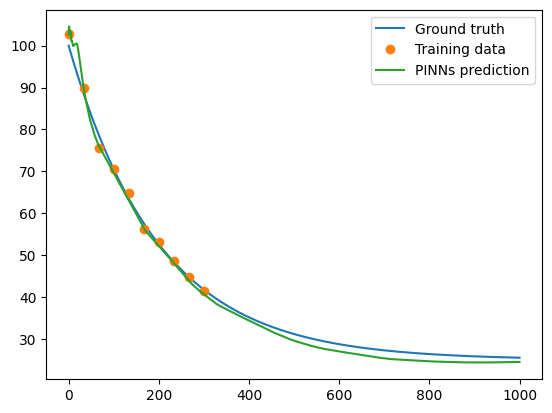

In [53]:
modelp.eval()
XT = torch.from_numpy(times).to(torch.float).to(device).reshape(len(times),-1)
out = modelp.forward(XT)
predp =out.detach().cpu().numpy()
pp.plot()
pp.plot(times,temps)
pp.plot(time,T_sample_noise,'o')
pp.plot(times, predp)
pp.legend(['Ground truth', 'Training data','PINNs prediction'])

In [54]:
class Networkdiscovery(network):
    def __init__(self,input_dim, out_dim,n_units=100)-> None:
        super().__init__(
            input_dim, out_dim, n_units
        )
        self.n_units = n_units
        
        self.r = nn.Parameter(data=torch.tensor([0.])) #what is this doing here? I am not really sure! 
Netdisc = Networkdiscovery(1,1,100)
print(Netdisc,Netdisc.r)
for name, param in Netdisc.named_parameters():
    print(name, param)

Networkdiscovery(
  (layers): Sequential(
    (0): Linear(in_features=1, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=100, bias=True)
    (5): ReLU()
    (6): Linear(in_features=100, out_features=100, bias=True)
    (7): ReLU()
  )
  (out): Linear(in_features=100, out_features=1, bias=True)
) Parameter containing:
tensor([0.], requires_grad=True)
r Parameter containing:
tensor([0.], requires_grad=True)
layers.0.weight Parameter containing:
tensor([[ 0.0369],
        [ 0.1624],
        [ 0.9786],
        [-0.1001],
        [ 0.5985],
        [ 0.5111],
        [-0.1041],
        [-0.2347],
        [-0.8927],
        [-0.0422],
        [-0.6859],
        [ 0.0442],
        [-0.5517],
        [-0.2129],
        [-0.6185],
        [ 0.3857],
        [ 0.6138],
        [-0.3512],
        [-0.9889],
        [-0.3844],
        [ 0.7873],
        [ 0.7482],
        [-0.71

In [55]:
def physics_loss_discovery(model: torch.nn.Module):
    ts = torch.linspace(0, 1000, steps=1000,).view(-1,1).requires_grad_(True).to(device)
    temps = model(ts)
    dT = grad(temps, ts)[0]
    pde = model.r * (25 - temps) - dT
    
    return torch.mean(pde**2)

Networkdiscovery(
  (layers): Sequential(
    (0): Linear(in_features=1, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=100, bias=True)
    (5): ReLU()
    (6): Linear(in_features=100, out_features=100, bias=True)
    (7): ReLU()
  )
  (out): Linear(in_features=100, out_features=1, bias=True)
) 0.001
torch.Size([10, 1]) torch.Size([10, 1])
Epoch 0/20000,loss: 4713.875
Epoch 2000/20000,loss: 2522.218
Epoch 4000/20000,loss: 2105.351
Epoch 6000/20000,loss: 551.221
Epoch 8000/20000,loss: 29.200
Epoch 10000/20000,loss: 0.866
Epoch 12000/20000,loss: 0.403
Epoch 14000/20000,loss: 0.345
Epoch 16000/20000,loss: 0.312
Epoch 18000/20000,loss: 0.293
<class 'list'>


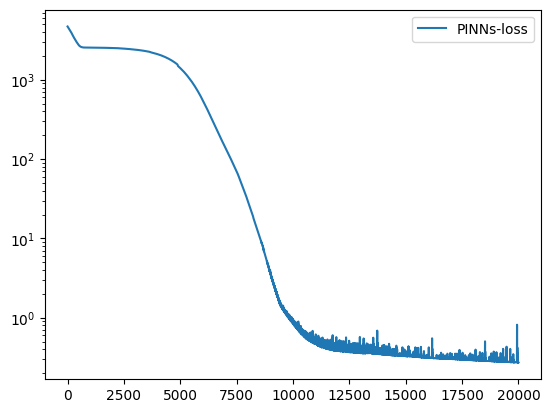

In [56]:
torch.manual_seed(42)
epochs = 20000
lr = 1e-5
weight=0.001
modelp2 = Networkdiscovery(1,1,100).to(device)
print(modelp2,weight)
optimizer =torch.optim.Adam(modelp2.parameters(),lr=lr,weight_decay=weight)

#np to torch#   
#X = torch.from_numpy(time).to(torch.float).to(device).reshape(len(time),-1)
#Y = torch.from_numpy(T_sample_noise).to(torch.float).to(device).reshape(len(T_sample_noise),-1)
print(X.size(),Y.size())
losses =[]
data_loss = nn.MSELoss()
modelp2.train()
for epoch in range(epochs):
    ##forward pass
    optimizer.zero_grad() #this zeros out the gradients
    output =modelp2.forward(X).requires_grad_(True)
    #print(type(output))
    #output = torch.tensor(output,requires_grad = True)
    data_loss = nn.MSELoss()
    loss = data_loss(Y,output) + physics_loss_discovery(modelp2)
    #print(loss.item())
    loss.backward()
    ##update weights
    optimizer.step()
    #update losses, print progress
    losses.append(loss.item())
    if epoch % int(epochs/10) == 0:
        print(f"Epoch {epoch}/{epochs},loss: {losses[-1]:.3f}")
#safe models
print(type(losses))
pp.plot(losses)
pp.yscale('log')
pp.legend(['PINNs-loss'])

Parameter containing:
tensor([0.0056], device='mps:0', requires_grad=True)


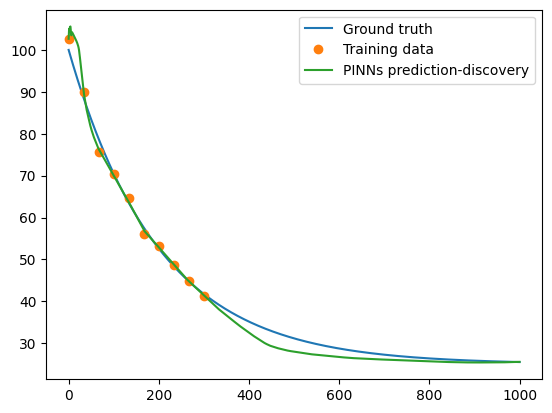

In [57]:
modelp2.eval()
XT = torch.from_numpy(times).to(torch.float).to(device).reshape(len(times),-1)
out = modelp2.forward(XT)
predp2 =out.detach().cpu().numpy()
print(modelp2.r)
pp.plot()
pp.plot(times,temps)
pp.plot(time,T_sample_noise,'o')
pp.plot(times, predp2)
pp.legend(['Ground truth', 'Training data','PINNs prediction-discovery'])

Networkdiscovery(
  (layers): Sequential(
    (0): Linear(in_features=1, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=100, bias=True)
    (5): ReLU()
    (6): Linear(in_features=100, out_features=100, bias=True)
    (7): ReLU()
  )
  (out): Linear(in_features=100, out_features=1, bias=True)
) 0.0
torch.Size([10, 1]) torch.Size([10, 1])
Epoch 0/40000,loss: 4622.787
Epoch 4000/40000,loss: 2484.814
Epoch 8000/40000,loss: 1926.755
Epoch 12000/40000,loss: 174.613
Epoch 16000/40000,loss: 1.601
Epoch 20000/40000,loss: 0.601
Epoch 24000/40000,loss: 0.417
Epoch 28000/40000,loss: 0.350
Epoch 32000/40000,loss: 0.332
Epoch 36000/40000,loss: 0.328
<class 'list'>


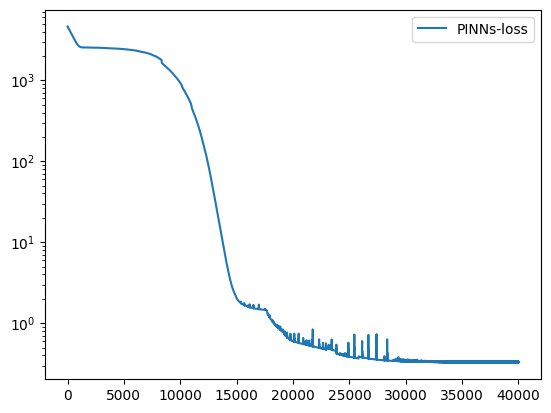

In [58]:
epochs = 40000
lr = 5e-6
weight=0.000
modelp2 = Networkdiscovery(1,1,100).to(device)
print(modelp2,weight)
optimizer =torch.optim.Adam(modelp2.parameters(),lr=lr,weight_decay=weight)

#np to torch#   
#X = torch.from_numpy(time).to(torch.float).to(device).reshape(len(time),-1)
#Y = torch.from_numpy(T_sample_noise).to(torch.float).to(device).reshape(len(T_sample_noise),-1)
print(X.size(),Y.size())
losses =[]
data_loss = nn.MSELoss()
modelp2.train()
for epoch in range(epochs):
    ##forward pass
    optimizer.zero_grad() #this zeros out the gradients
    output =modelp2.forward(X).requires_grad_(True)
    #print(type(output))
    #output = torch.tensor(output,requires_grad = True)
    data_loss = nn.MSELoss()
    loss = data_loss(Y,output) + physics_loss_discovery(modelp2)
    #print(loss.item())
    loss.backward()
    ##update weights
    optimizer.step()
    #update losses, print progress
    losses.append(loss.item())
    if epoch % int(epochs/10) == 0:
        print(f"Epoch {epoch}/{epochs},loss: {losses[-1]:.3f}")
#safe models
print(type(losses))
pp.plot(losses)
pp.yscale('log')
pp.legend(['PINNs-loss'])